# Model Training and Evaluation Setup

This setup defines which data to use for training and testing a model.

There are two standard training and test options.
1. train_specification = ‘1_to_25_80p’ with test_specification = '26_to_50_100p'
2. train_specification = ‘26_to_50_80p’ with test_specification = '1_to_25_100p'

e.g. 1_to_25_80p: _1_to_25 means question block 1, with 80 percent of the data_

In [1]:
train_specification = '1_to_25_80p'
test_specification = '26_to_50_100p'

___
--There is a separate notebook for the traceability of the training- and testdata: \_split_train_test_data.ipynb--

# Dataset Preperation

In [2]:
import pandas as pd
train_df = pd.read_json(f'training_splits/train_{train_specification}.json')
train_df.columns = ['query', 'answer', 'label']

In [3]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "sentence1": [row['query'] for _, row in train_df.iterrows()],
    "sentence2": [row['answer'] for _, row in train_df.iterrows()],
    "label": [int(row['label']) for _, row in train_df.iterrows()],
})

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Training

In [4]:
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, losses, SentenceTransformerTrainingArguments

In [5]:
basemodel = SentenceTransformer('all-mpnet-base-v2')
model_name = 'new_trained_sentence_transformer'  # arbitrary

In [6]:
args = SentenceTransformerTrainingArguments(model_name,  num_train_epochs = 1)

In [7]:
trainer = SentenceTransformerTrainer(
    args=args,
    model=basemodel,
    train_dataset=train_dataset,    
    loss=losses.ContrastiveLoss(basemodel)
)
trainer.train()

Step,Training Loss


TrainOutput(global_step=37, training_loss=0.02253821733835581, metrics={'train_runtime': 99.8232, 'train_samples_per_second': 2.925, 'train_steps_per_second': 0.371, 'total_flos': 0.0, 'train_loss': 0.02253821733835581, 'epoch': 1.0})

In [8]:
trainer.save_model(model_name)

# Evaluation

In [9]:
import json

json__testdata_sentence = f'test_splits/test_{test_specification}.json'

with open(json__testdata_sentence, 'r') as sen_test_file:
    test_set = json.load(sen_test_file)

In [10]:
import os
from sentence_transformers import SentenceTransformer

def save_scores(model_name):
    model = SentenceTransformer(model_name)

    y_score = []  # score of model
    y_true = []   # score of human

    for document in test_set:
        document_query = document[0]
        document_answer = document[1]
        our_answer = document[2]

        embeddings = model.encode([document_answer, document_query])
        similarity = model.similarity(embeddings, embeddings)

        y_score.append(float(similarity[0][1]))
        y_true.append(our_answer)

    scores = list(zip(y_score, y_true))

    output_dir = f"evaluation_area/{model_name}"
    os.makedirs(output_dir, exist_ok=True)

    filename_scores = f"{output_dir}/{test_specification}.json"
    with open(filename_scores, 'w') as json_file:
        json.dump(scores, json_file, indent=4)

save_scores(model_name=model_name)

# ROC

In [11]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [12]:
def get_statistic_scores(model_name, filename_tested):         
    
    filename_scores = f"evaluation_area/{model_name}/{filename_tested}.json"
    with open(filename_scores, "r", encoding="utf-8") as file:
        data_scores = json.load(file)
        y_score = [x[0] for x in data_scores]
        y_true = [x[1] for x in data_scores]
        
    filename_model_info_training =  f"evaluation_area/_trainings_overview.json"
    with open(filename_model_info_training, "r", encoding="utf-8") as trainingfile:
        data_info_model = json.load(trainingfile)     
        for model in data_info_model:
            if model == model_name:
                model_info_training = data_info_model[model_name] 
                break
            else:
                model_info_training = train_specification
    
    return y_score, y_true, model_info_training

In [13]:
def build_roc_curve(model_names, filename_tested, colors, labels=True):
    plt.figure()

    legend_entries = []

    for model in model_names:
        y_score, y_true, model_info_training = get_statistic_scores(model_name = model, filename_tested=filename_tested)
        
        fpr, tpr, thresholds = roc_curve(y_true=y_true, y_score=y_score, pos_label='1')
        roc_auc = auc(fpr,tpr)
        
        color = colors.pop()        
        legend_entries.append(f'ROC {model} (area = {roc_auc:.2f}) {model_info_training}')
        
        plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC {model} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    
    if labels == True:
        plt.title(f'Testdata: {filename_tested}')        
        plt.figtext(0.5, -0.1, "\n".join(legend_entries), wrap=True, horizontalalignment='center', fontsize=10)        
        plt.savefig(f"roc_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    else:        
        plt.savefig(f"roc_{model}-{filename_tested[:-8]}.svg", format="svg", bbox_inches="tight")
    
    plt.show()

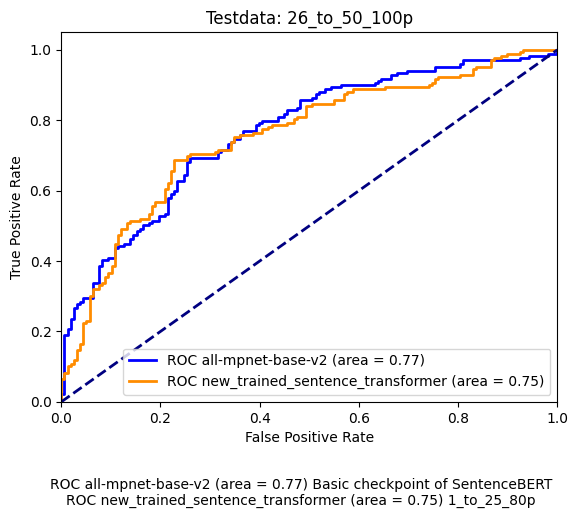

In [14]:
build_roc_curve(model_names = ['all-mpnet-base-v2', model_name], 
                filename_tested = test_specification,
                colors=['red', 'darkorange', 'blue'])

# Boxplot

In [15]:
import seaborn as sns
import numpy as np

# Prepare data for the boxplot
# y_bool = [0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
# y_scores = [0.2, 0.8, 0.4, 0.9, 0.85, 0.1, 0.6, 0.3, 0.75, 0.05]

def build_boxplot(model, filename_tested, ylimbot=None, ylimtop=None):    

    y_score, y_true, model_info_training = get_statistic_scores(model_name = model,                                                                 
                                                                filename_tested=filename_tested)    
    
    y_true = np.array([int(i) for i in y_true])
    y_score = np.array(y_score)
    scores_by_class = [y_score[y_true == 0], y_score[y_true == 1]] 
      
    plt.figure(figsize=(0.5, 6))
    sns.boxplot(data=scores_by_class)
    plt.xticks([0, 1], labels=['Irrelevant', 'Relevant'], rotation=45, ha='right', fontsize=11)    
    plt.ylabel('Predicted Scores') 
    if ylimbot != None:      
        plt.ylim(ylimbot, ylimtop)
    plt.title(model, fontsize=10, fontweight = 'bold', pad=15)
    plt.figtext(1, -0.2, f'Tested:  {filename_tested} \n\n Trained: {model_info_training}', wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f"bp_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    plt.show()

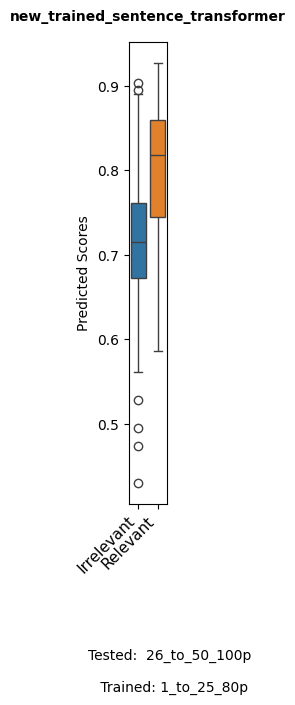

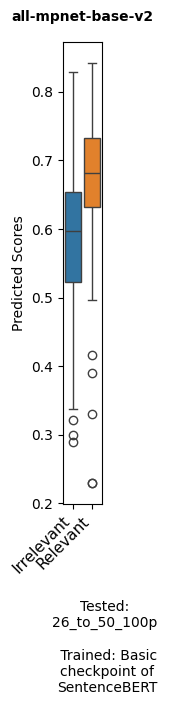

In [16]:
build_boxplot(model_name, test_specification)
build_boxplot('all-mpnet-base-v2', test_specification)